En este notebook, realizaremos los trabajos necesarios con respecto a nuestras variables y comenzaremos a aplicar el modelo de regresión logistica, aunque el mismo sigue en proceso de evaluación y no ha sido finalizado aún.


In [ ]:
# Importamos librerias a utilizar
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [4]:
#Cargamos el dataset y lo transformamos en un DataFrame de pandas para poder manipularlo de manera más sencilla.

data, meta = arff.loadarff("/Users/Camila/Desktop/datasets/dataset_31_credit-g.arff")
df = pd.DataFrame(data)

#Decodificamos los strings que provienen del archivo ARFF para que sean legibles y consistentes en el DataFrame.
for column in df.select_dtypes([object]).columns:
    df[column] = df[column].str.decode('utf-8')

In [ ]:
#Mapeamos las variables categoricas binarias a 0 y 1
df['foreign_worker'] = df['foreign_worker'].map({ 'yes' : 0, 'no' : 1
})
df['class'] = df['class'].map({'good':1, 'bad':0})  # clase 1 = clase buena, clase 0 = clase mala
df['own_telephone'] = df['own_telephone'].map({ 'yes' : 1, 'none' : 0
})

#Separamos las columnas que le realizaremos OneHotEncoder y las que no
columnas_onehot = [] 
columnas_binarias = ['class', 'own_telephone', 'foreign_worker']
columnas_numericas = []


### Dividimos los datos en entrenamiento y test, antes de realizar transformaciones, para evitar data leakage 

In [6]:
# 2. Separar características (X) de la variable objetivo (y)
X = df.drop(columns=['class']) # Sacamos 'class' para que no entre al Pipeline
y = df['class']

# 3. Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:

#Agregamos las columnas categoricas a la lista de columnas_onehot y las numericas a la lista de columnas_numericas
for col in X_train.columns:
    if col in X_train.select_dtypes(include=["object"]).columns and col not in columnas_binarias:
        columnas_onehot.append(col)
        print(f"{col}: {X_train[col].unique()}\n")
    elif col in X_train.select_dtypes(include=["int64", "float64"]).columns and col not in columnas_binarias:
        columnas_numericas.append(col)

In [10]:
#Creamos un pipeline para transformar nuestras variables categoricas en variables numericas, y estandarizar las numericas

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(), columnas_onehot),
        ('num', StandardScaler(), columnas_numericas)
    ], remainder="passthrough"
)

pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

In [11]:
# El Pipeline ejecutará internamente .fit_transform() SOLO con los datos de train
X_train_procesado = pipeline.fit_transform(X_train)

# El Pipeline aplicará SOLO .transform() en test (Cero Leakage)
X_test_procesado = pipeline.transform(X_test)

In [12]:
X_train_procesado.shape, X_test_procesado.shape

((800, 59), (200, 59))

In [47]:
pesos = {0: 5, 1: 1} #la clase 0 (mala) tiene un peso de 5 y la clase 1 (buena) tiene un peso de 1

pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    # penalty='l2' es por defecto. C=1.0 es el valor estándar.
    ('classifier', LogisticRegression(class_weight=pesos, penalty='l2', solver='newton-cg', max_iter=3000))
])

# 2. Entrenar el modelo con los datos de entrenamiento
pipeline_final.fit(X_train, y_train)

# Esto devuelve [probabilidad_clase_0, probabilidad_clase_1] por cada fila
probabilidades = pipeline_final.predict_proba(X_test)
probabilidades_clase_1 = probabilidades[:, 1]

umbral_personalizado = 0.6
predicciones_personalizadas = (probabilidades_clase_1 >= umbral_personalizado).astype(int)

# 5. Evaluar los resultados con el nuevo umbral
print(classification_report(y_test, predicciones_personalizadas))

              precision    recall  f1-score   support

           0       0.40      0.95      0.56        60
           1       0.95      0.39      0.56       140

    accuracy                           0.56       200
   macro avg       0.67      0.67      0.56       200
weighted avg       0.78      0.56      0.56       200



Matriz de Confusión Numérica:
[[57  3]
 [85 55]]


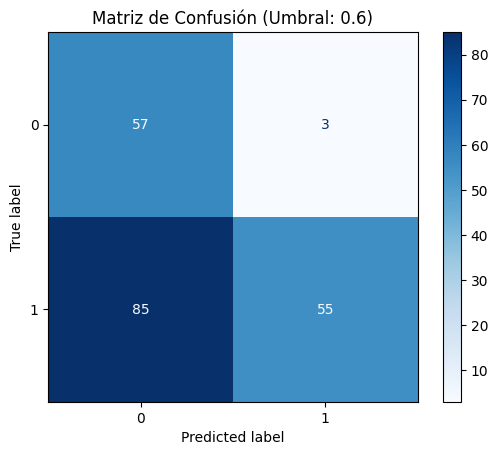

In [48]:
# 1. Calcular la matriz de confusión numérica
# (y_test son los valores reales, predicciones_personalizadas son las del umbral)
cm = confusion_matrix(y_test, predicciones_personalizadas)

print("Matriz de Confusión Numérica:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=pipeline_final.classes_ # Muestra tus etiquetas originales (0:bad y 1:good)
)

disp.plot(cmap=plt.cm.Blues)

plt.title(f"Matriz de Confusión (Umbral: {umbral_personalizado})")
plt.show()

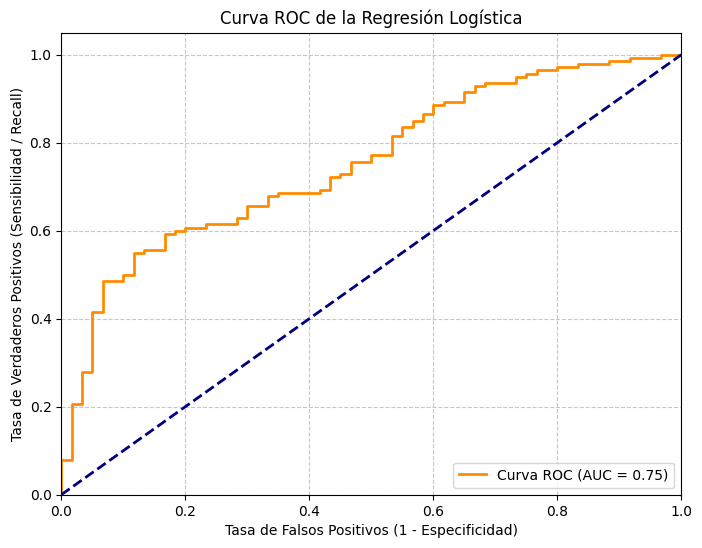

In [ ]:
# 1. Calcular los ratios de falsos positivos (fpr) y verdaderos positivos (tpr)
fpr, tpr, thresholds = roc_curve(y_test, probabilidades_clase_1)

# 2. Calcular el área bajo la curva (AUC)
roc_auc = auc(fpr, tpr)

# 3. Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')

# Graficar la línea diagonal de referencia (un modelo aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Configuración de etiquetas y límites del gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)')
plt.title('Curva ROC de la Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()


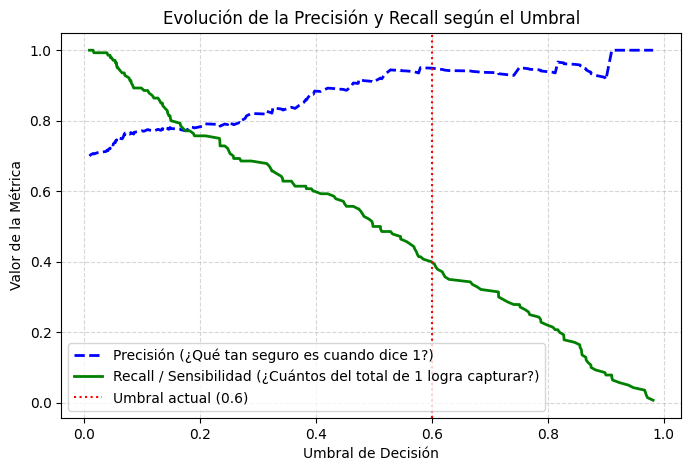

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# 1. Calcular precisión y recall para todos los umbrales posibles
precisions, recalls, thresholds = precision_recall_curve(y_test, probabilidades_clase_1)

# 2. Graficar cómo cambia la precisión según el umbral
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precisión (¿Qué tan seguro es cuando dice 1?)', lw=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall / Sensibilidad (¿Cuántos del total de 1 logra capturar?)', lw=2)

# Dibujar una línea en tu umbral actual (0.6)
plt.axvline(x=0.6, color='red', linestyle=':', label='Umbral actual (0.6)')

plt.xlabel('Umbral de Decisión')
plt.ylabel('Valor de la Métrica')
plt.title('Evolución de la Precisión y Recall según el Umbral')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### Ver los parámetros de nuestra regresión

In [ ]:
#Extraemos el modelo de regresión logística entrenado desde el pipeline
modelo_lr = pipeline_final.named_steps['classifier']

# Para obtener el intercepto
interseccion = modelo_lr.intercept_[0]

#Obtener los parámetros 
coeficientes = modelo_lr.coef_[0]

print(f"Intersección (Intercept / b0): {interseccion}\n")

# 4. Mostrar los coeficientes junto al nombre de cada variable
# Nota: Reemplaza 'nombre_de_las_columnas' por la lista de nombres que generó tu 'preprocessor'
try:
    nombres_columnas = pipeline_final.named_steps['preprocessor'].get_feature_names_out()
    print("Coeficientes por variable:")
    for col, coef in zip(nombres_columnas, coeficientes):
        print(f" - {col}: {coef:.4f}")
except AttributeError:
    print("Coeficientes (ordenados según entraron al clasificador):")
    print(coeficientes)


Intersección (Intercept / b0): -1.0960357305313806

Coeficientes por variable:
 - cat__checking_status_0<=X<200: -0.3585
 - cat__checking_status_<0: -0.7191
 - cat__checking_status_>=200: -0.0265
 - cat__checking_status_no checking: 1.0938
 - cat__credit_history_all paid: -0.3295
 - cat__credit_history_critical/other existing credit: 0.8683
 - cat__credit_history_delayed previously: -0.0713
 - cat__credit_history_existing paid: 0.0114
 - cat__credit_history_no credits/all paid: -0.4892
 - cat__purpose_business: -0.0120
 - cat__purpose_domestic appliance: -0.1059
 - cat__purpose_education: -1.0542
 - cat__purpose_furniture/equipment: 0.0579
 - cat__purpose_new car: -0.7299
 - cat__purpose_other: -0.0024
 - cat__purpose_radio/tv: 0.2952
 - cat__purpose_repairs: -0.7427
 - cat__purpose_retraining: 0.5863
 - cat__purpose_used car: 1.6974
 - cat__savings_status_100<=X<500: 0.0179
 - cat__savings_status_500<=X<1000: -0.4176
 - cat__savings_status_<100: -0.5656
 - cat__savings_status_>=1000: 

Conclusiones hasta ahora:
El modelo está sesgado en predecir la clase 0, es decir, aproximadamente la mitad de las veces clasificó las observaciones como créditos riesgosos. Esto puede comprenderse debido a los pesos que se le han asignado al modelo. Recordemos que se había establecido que "es 5 veces peor clasificar a un usuario como bueno cuando es malo, que clasificarlo como malo cuando es bueno", lo cual obligará al modelo a aprender y penalizar mayormente dichas equivocaciones.

Debemos continuar optimizando el modelo para obtener mejores resultados, para ello debemos definir el umbral de decisión que optimice el modelo. (continuar)